In [1]:
from Charts.ploTools import *
from Charts.resumeTools import *

In [2]:
PREFIX_EXP = "OptimizeIterationsResults/OptunaDDPGExpBase_*" # 

EXPERIMENTS_PATHS = glob(f"{PREFIX_EXP}")
EXPERIMENTS_PATHS.remove('OptimizeIterationsResults\\OptunaDDPGExpBase_RewardNetProfit_ShuffleDaysTrue')
EXPERIMENTS_PATHS.remove('OptimizeIterationsResults\\OptunaDDPGExpBase_RMemorySize3_NetProfit')
EXPERIMENTS_PATHS

['OptimizeIterationsResults\\OptunaDDPGExpBase_CorrelationPunishment05',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_CorrelationPunishment07',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RewardNetProfit',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RMemorySize10',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RMemorySize3',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_ShuffleDaysTrue',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_Total']

In [5]:
finalResults = getResumeDataTestingDDPGAgent(EXPERIMENTS_PATHS)
#finalTrainResults = getResumeDataTrainingDDPGAgent(EXPERIMENTS_PATHS)

In [15]:
randomResults = getResumeDataTestingDDPGAgent(['OptimizeIterationsResults\\OptunaDDPGExpBase_Total'],agent_name='Random Agent')
SP500Results = getResumeDataTestingDDPGAgent(['OptimizeIterationsResults\\OptunaDDPGExpBase_Total'],agent_name='SP500 Agent')

In [21]:
finalResults['Random Agent'] = randomResults['TotalRandom Agent']
finalResults['SP500 Agent'] = SP500Results['TotalSP500 Agent']

In [ ]:
finalResults.keys()


dict_keys(['CorrelationPunishment05DDPG Agent', 'CorrelationPunishment07DDPG Agent', 'RewardNetProfitDDPG Agent', 'RMemorySize10DDPG Agent', 'RMemorySize3DDPG Agent', 'ShuffleDaysTrueDDPG Agent', 'TotalDDPG Agent', 'Random Agent', 'SP500 Agent'])

In [30]:
del finalResults['ShuffleDaysTrueDDPG Agent']

In [31]:
filename = "dataChartsForPaper/dataResume.pkl"

# Save the dictionary as a JSON file
import pickle
try:
    with open(filename, "wb") as file:
        pickle.dump(finalResults, file)  # indent=4 for pretty printing
    print(f"Dictionary successfully saved to {filename}")
except IOError as e:
    print(f"Error saving file: {e}")

Dictionary successfully saved to dataChartsForPaper/dataResume.pkl


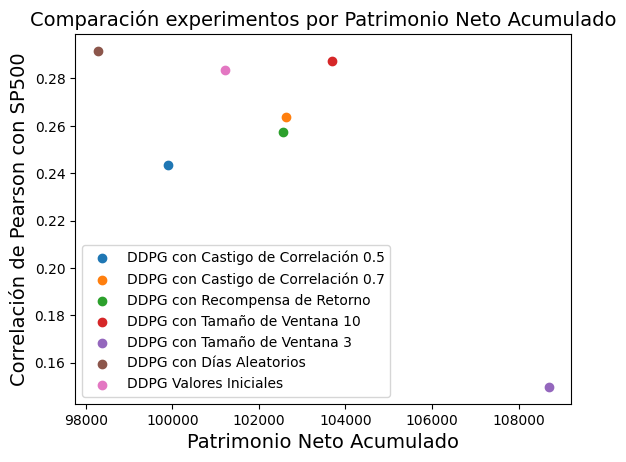

In [10]:
##G8
label_list_dict = {'TotalDDPG Agent': 'DDPG Valores Iniciales', 
                   'ShuffleDaysTrueDDPG Agent': 'DDPG con Días Aleatorios',
                   'RewardNetProfitDDPG Agent': 'DDPG con Recompensa de Retorno',
                   'CorrelationPunishment05DDPG Agent': 'DDPG con Castigo de Correlación 0.5',
                   'CorrelationPunishment07DDPG Agent': 'DDPG con Castigo de Correlación 0.7',              
                   'RMemorySize3DDPG Agent': 'DDPG con Tamaño de Ventana 3',
                   'RMemorySize10DDPG Agent': 'DDPG con Tamaño de Ventana 10',
                   'title': 'Comparación experimentos por Patrimonio Neto Acumulado',
                   'xlabel': 'Patrimonio Neto Acumulado',
                   'ylabel': 'Correlación de Pearson con SP500',}

plotScatterAandB(X='net_worths_delta_acum', Y='pearson_correlations', finalResults=finalResults, path_to_save='G8_compareNetWorthsCorrelation', label_list_dict=label_list_dict)

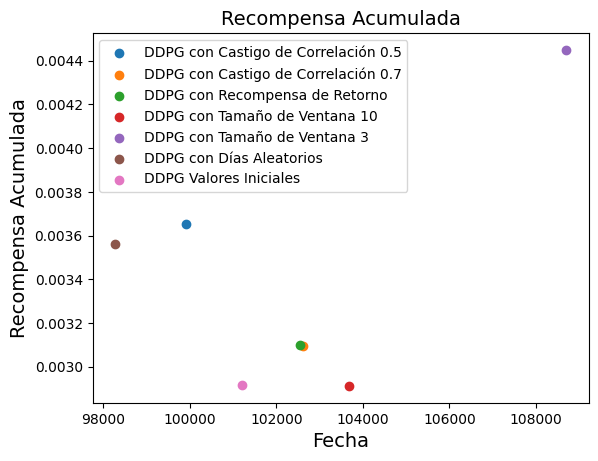

In [12]:
label_list_dict = {'TotalDDPG Agent': 'DDPG Valores Iniciales', 
                   'ShuffleDaysTrueDDPG Agent': 'DDPG con Días Aleatorios',
                   'RewardNetProfitDDPG Agent': 'DDPG con Recompensa de Retorno',
                   'CorrelationPunishment05DDPG Agent': 'DDPG con Castigo de Correlación 0.5',
                   'CorrelationPunishment07DDPG Agent': 'DDPG con Castigo de Correlación 0.7',              
                   'RMemorySize3DDPG Agent': 'DDPG con Tamaño de Ventana 3',
                   'RMemorySize10DDPG Agent': 'DDPG con Tamaño de Ventana 10',
                   'title': 'Recompensa Acumulada',
                   'xlabel': 'Fecha',
                   'ylabel': 'Recompensa Acumulada',}
plotScatterAandB(X='net_worths_delta_acum', Y='stds', finalResults=finalResults, path_to_save='G9_compareNetWorthsSTDS', label_list_dict=label_list_dict)

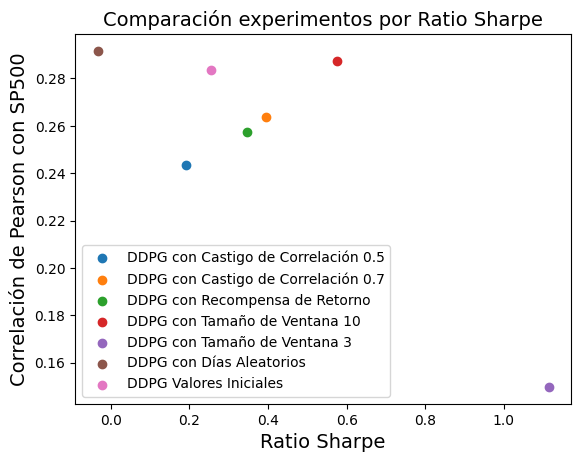

In [11]:
##G8
label_list_dict = {'TotalDDPG Agent': 'DDPG Valores Iniciales', 
                   'ShuffleDaysTrueDDPG Agent': 'DDPG con Días Aleatorios',
                   'RewardNetProfitDDPG Agent': 'DDPG con Recompensa de Retorno',
                   'CorrelationPunishment05DDPG Agent': 'DDPG con Castigo de Correlación 0.5',
                   'CorrelationPunishment07DDPG Agent': 'DDPG con Castigo de Correlación 0.7',              
                   'RMemorySize3DDPG Agent': 'DDPG con Tamaño de Ventana 3',
                   'RMemorySize10DDPG Agent': 'DDPG con Tamaño de Ventana 10',
                   'title': 'Comparación experimentos por Ratio Sharpe',
                   'xlabel': 'Ratio Sharpe',
                   'ylabel': 'Correlación de Pearson con SP500',}

plotScatterAandB(X='sharpe_ratios', Y='pearson_correlations', finalResults=finalResults, path_to_save='G10_sharpeVsCorrelation', label_list_dict=label_list_dict)